In [2]:
from Bio.PDB import PDBParser

parser = PDBParser(QUIET=True)

structure = parser.get_structure(
    "EGFR",
    "../data/pdb/4WKQ.pdb"
)

print("Structure loaded successfully!")

Structure loaded successfully!


In [3]:
for model in structure:
    print("Model ID:", model.id)

    for chain in model:
        residues = list(chain.get_residues())
        print(f"Chain {chain.id}: {len(residues)} residues")

Model ID: 0
Chain A: 421 residues


In [4]:
for model in structure:
    for chain in model:
        for residue in chain:
            if residue.id[0] != " ":
                print(
                    "Chain:",
                    chain.id,
                    "Residue:",
                    residue.resname
                )

Chain: A Residue: CSX
Chain: A Residue: IRE
Chain: A Residue: NA
Chain: A Residue: MES
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Residue: HOH
Chain: A Re

In [5]:
ligand = None

for model in structure:
    for chain in model:
        for residue in chain:
            if residue.resname == "IRE":
                ligand = residue
                break

print(ligand)

<Residue IRE het=H_IRE resseq=1101 icode= >


In [6]:
from Bio.PDB import NeighborSearch

atoms = list(structure.get_atoms())

ns = NeighborSearch(atoms)

binding_residues = set()

for atom in ligand:
    
    nearby_atoms = ns.search(
        atom.coord,
        5.0
    )
    
    for nearby_atom in nearby_atoms:
        
        residue = nearby_atom.get_parent()
        
        if residue.id[0] == " ":
            binding_residues.add(
                (
                    residue.resname,
                    residue.id[1]
                )
            )

for residue in sorted(binding_residues,
                      key=lambda x: x[1]):
    print(residue)

('LEU', 718)
('GLY', 719)
('VAL', 726)
('ALA', 743)
('ILE', 744)
('LYS', 745)
('GLU', 762)
('MET', 766)
('LEU', 788)
('ILE', 789)
('THR', 790)
('GLN', 791)
('LEU', 792)
('MET', 793)
('PRO', 794)
('PHE', 795)
('GLY', 796)
('ASP', 800)
('LEU', 844)
('THR', 854)
('ASP', 855)


In [7]:
import pandas as pd

df = pd.DataFrame(
    sorted(binding_residues,
           key=lambda x: x[1]),
    columns=["Residue", "Position"]
)

df

,Residue,Position
0,LEU,718
1,GLY,719
2,VAL,726
3,ALA,743
4,ILE,744
5,LYS,745
6,GLU,762
7,MET,766
8,LEU,788
9,ILE,789


In [8]:
df.to_csv(
    "../results/reports/egfr_gefitinib_binding_residues.csv",
    index=False
)

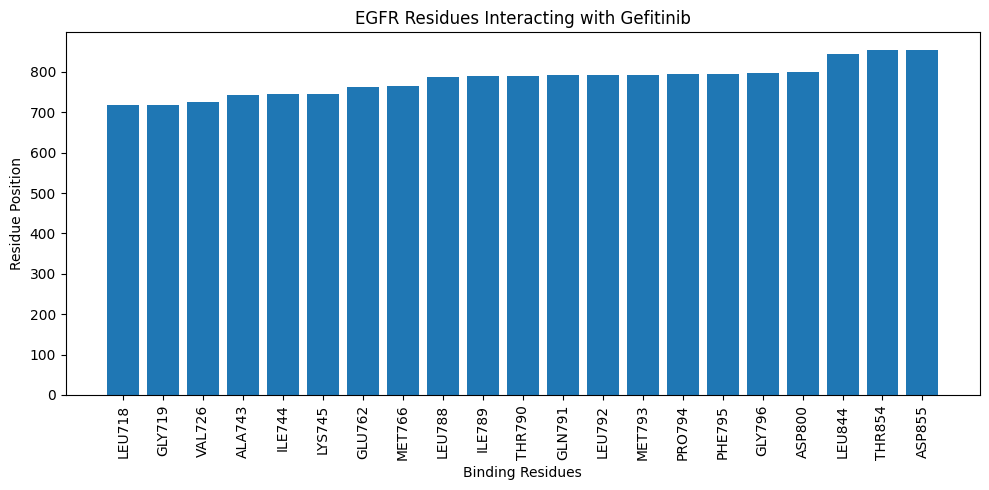

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../results/reports/egfr_gefitinib_binding_residues.csv"
)

plt.figure(figsize=(10,5))

plt.bar(
    df["Residue"] + df["Position"].astype(str),
    df["Position"]
)

plt.xticks(rotation=90)

plt.xlabel("Binding Residues")
plt.ylabel("Residue Position")
plt.title("EGFR Residues Interacting with Gefitinib")

plt.tight_layout()
plt.show()

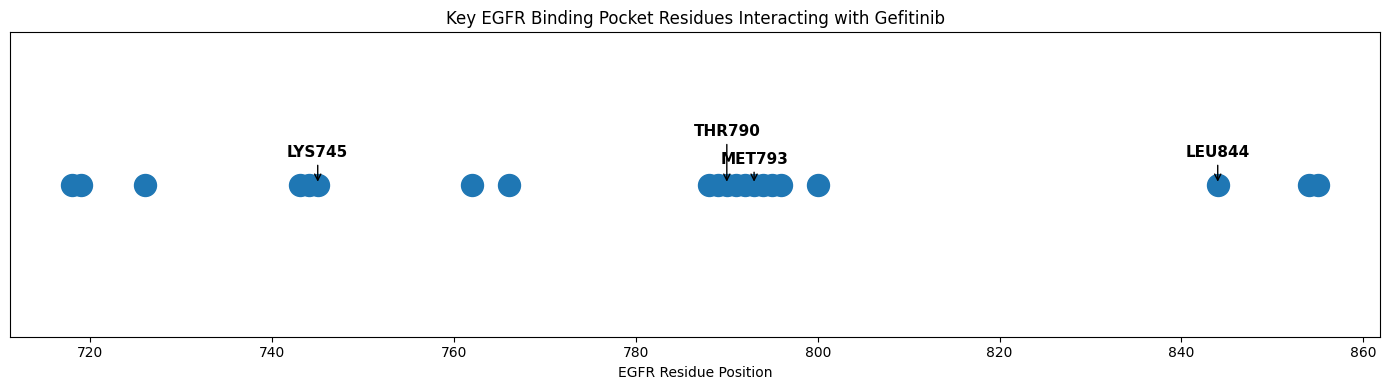

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../results/reports/egfr_gefitinib_binding_residues.csv")

plt.figure(figsize=(14,4))

plt.scatter(df["Position"], [1]*len(df), s=250)

label_offsets = {
    745: 20,
    790: 35,
    793: 15,
    844: 20
}

for _, row in df.iterrows():

    if row["Position"] in label_offsets:

        plt.annotate(
            f"{row['Residue']}{row['Position']}",
            (row["Position"], 1),
            xytext=(0, label_offsets[row["Position"]]),
            textcoords="offset points",
            ha="center",
            fontsize=11,
            fontweight="bold",
            arrowprops=dict(arrowstyle="->")
        )

plt.yticks([])
plt.xlabel("EGFR Residue Position")
plt.title("Key EGFR Binding Pocket Residues Interacting with Gefitinib")

plt.tight_layout()
plt.savefig(
    "../results/images/egfr_binding_pocket_residues.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
import py3Dmol

with open("../data/pdb/4WKQ.pdb", "r") as f:
    pdb_data = f.read()

view = py3Dmol.view(width=900, height=600)

view.addModel(pdb_data, "pdb")

# Protein cartoon
view.setStyle(
    {"chain": "A"},
    {"cartoon": {"color": "spectrum"}}
)

# Gefitinib ligand (IRE)
view.setStyle(
    {"resn": "IRE"},
    {"stick": {"colorscheme": "greenCarbon"}}
)

view.zoomTo({"resn": "IRE"})

view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [16]:
import py3Dmol

with open("../data/pdb/4WKQ.pdb", "r") as f:
    pdb_data = f.read()

view = py3Dmol.view(width=1000, height=700)

view.addModel(pdb_data, "pdb")

# Protein
view.setStyle(
    {"chain":"A"},
    {"cartoon":{"color":"lightgray"}}
)

# Gefitinib
view.setStyle(
    {"resn":"IRE"},
    {"stick":{"colorscheme":"greenCarbon"}}
)

# Important residues
for resi in ["745","790","793","844"]:
    view.setStyle(
        {"resi":resi},
        {"stick":{"colorscheme":"orangeCarbon"}}
    )

view.zoomTo({"resn":"IRE"})

view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [17]:
important_residues = {
    745: "Catalytic Lysine",
    790: "Gatekeeper Residue",
    793: "Key Hydrogen Bond Residue",
    844: "Hydrophobic Pocket Residue"
}

for position, role in important_residues.items():
    print(f"Residue {position}: {role}")

Residue 745: Catalytic Lysine
Residue 790: Gatekeeper Residue
Residue 793: Key Hydrogen Bond Residue
Residue 844: Hydrophobic Pocket Residue


In [18]:
import pandas as pd

summary = pd.DataFrame({
    "Residue": ["LYS745", "THR790", "MET793", "LEU844"],
    "Biological Role": [
        "Catalytic residue",
        "Gatekeeper residue",
        "Hydrogen bond interaction",
        "Hydrophobic pocket"
    ]
})

summary

,Residue,Biological Role
0,LYS745,Catalytic residue
1,THR790,Gatekeeper residue
2,MET793,Hydrogen bond interaction
3,LEU844,Hydrophobic pocket


In [19]:
summary.to_csv(
    "../results/reports/key_binding_residues.csv",
    index=False
)